In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [50]:
df = pd.read_csv("tech_layoffs_hiring_trends_elite_v2.csv")
df.head()

,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,...,Moderate Hiring,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,...,Moderate Hiring,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,...,Hiring Freeze,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,...,Hiring Freeze,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,...,Moderate Hiring,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market


In [35]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               12000 non-null  object 
 1   company_name            12000 non-null  object 
 2   industry                12000 non-null  object 
 3   country                 12000 non-null  object 
 4   company_size            12000 non-null  object 
 5   month                   12000 non-null  object 
 6   year                    12000 non-null  int64  
 7   layoffs_count           12000 non-null  int64  
 8   layoff_percentage       12000 non-null  float64
 9   reason_for_layoffs      12000 non-null  object 
 10  ai_automation_impact    12000 non-null  float64
 11  ai_replacement_risk     12000 non-null  float64
 12  open_roles              12000 non-null  int64  
 13  hiring_trend            12000 non-null  object 
 14  remote_jobs_percentage  12000 non-null

In [52]:
# Step 0: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [53]:
df = pd.read_csv("tech_layoffs_hiring_trends_elite_v2.csv", encoding="latin-1")

In [54]:
print(df.head())

print(df.shape)

print(df.info())

  record_id company_name       industry    country company_size month  year  \
0        T0    Microsoft             AI  Singapore   Enterprise   Mar  2026   
1        T1     Palantir             AI     Canada     Big Tech   Feb  2024   
2        T2    Anthropic  Cybersecurity        USA     Mid-size   Apr  2025   
3        T3      Spotify         Gaming        USA     Mid-size   Jun  2025   
4        T4         Uber         Gaming         UK      Startup   Feb  2025   

   layoffs_count  layoff_percentage     reason_for_layoffs  ...  \
0            860                1.8          AI Automation  ...   
1            955                1.8           Cost Cutting  ...   
2          18912                9.5  Overhiring Correction  ...   
3          18159                9.1           Cost Cutting  ...   
4            815                3.3        Market Slowdown  ...   

      hiring_trend  remote_jobs_percentage     top_hiring_role  \
0  Moderate Hiring                    46.7         ML En

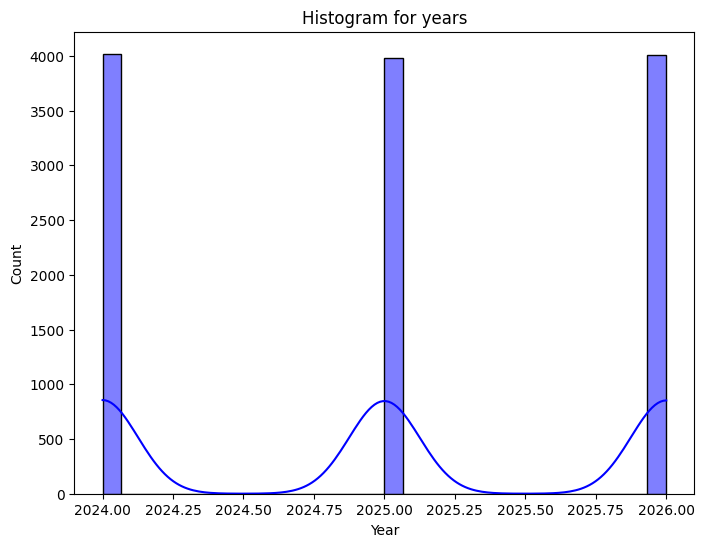

In [56]:
plt.figure(figsize=(8,6))
sns.histplot(df['year'].dropna(),bins=30,kde=True,color= 'blue')
plt.title('Histogram for years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

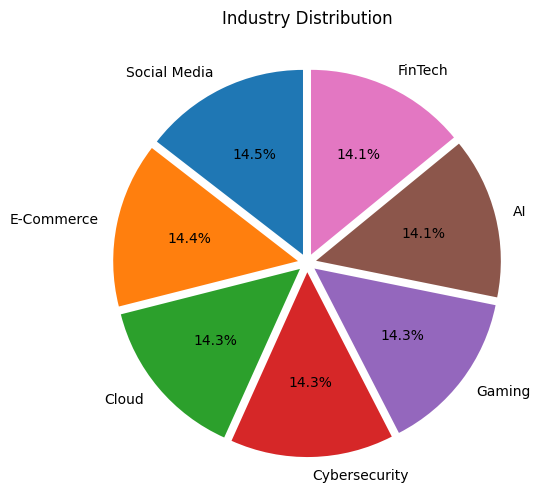

In [57]:
industry = df['industry'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(industry,labels=industry.index,
    autopct='%1.1f%%',startangle=90,explode=[0.05] * len(industry))
plt.title("Industry Distribution")
plt.show()

In [58]:
data = df['company_name'].value_counts()
data

company_name
Databricks    644
OpenAI        640
Spotify       638
Google        632
NVIDIA        616
Salesforce    615
Apple         615
Meta          611
Oracle        606
Netflix       599
Amazon        599
Intel         592
Uber          590
SAP           587
Microsoft     579
Stripe        578
Airbnb        572
Palantir      570
Anthropic     566
Adobe         551
Name: count, dtype: int64

C:\Users\JEYASHREE\AppData\Local\Temp\ipykernel_24000\1696635347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hiring_trend', y='open_roles', data=df, palette='Set2')


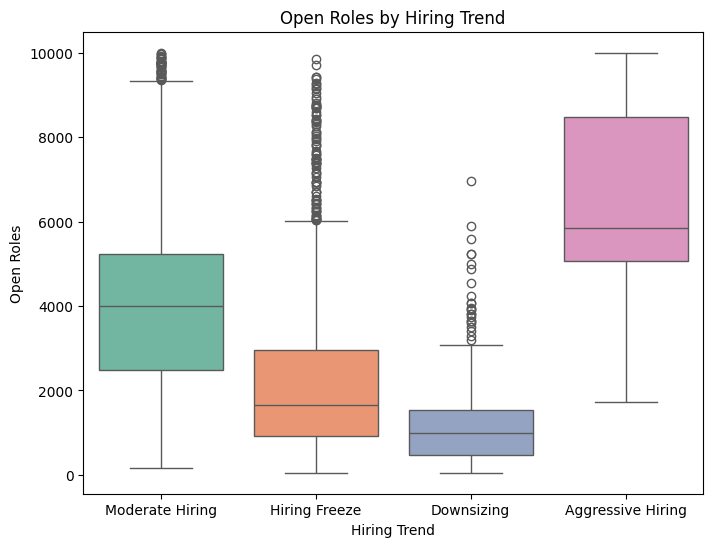

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='hiring_trend', y='open_roles', data=df, palette='Set2')
plt.title('Open Roles by Hiring Trend')
plt.xlabel('Hiring Trend')
plt.ylabel('Open Roles')
plt.show()

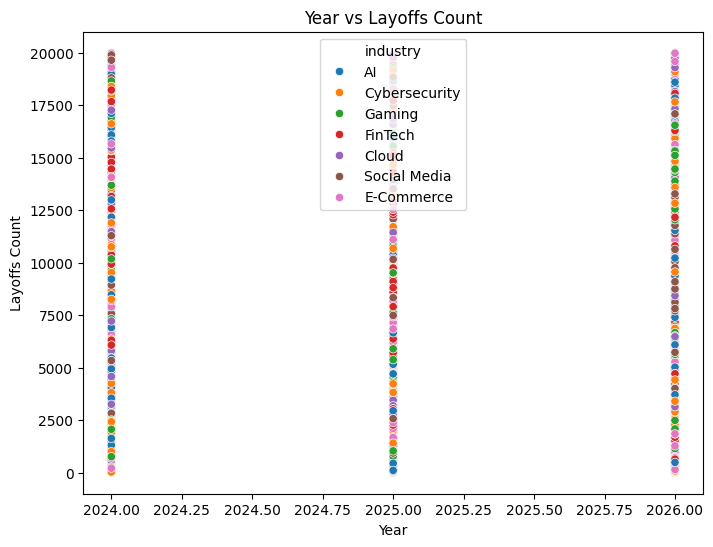

In [71]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='year',y='layoffs_count',hue='industry',data=df)
plt.title('Year vs Layoffs Count')
plt.xlabel('Year')
plt.ylabel('Layoffs Count')
plt.show()

C:\Users\JEYASHREE\AppData\Local\Temp\ipykernel_24000\1851093242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='company_size',y='layoffs_count',data=df,palette='Set3')


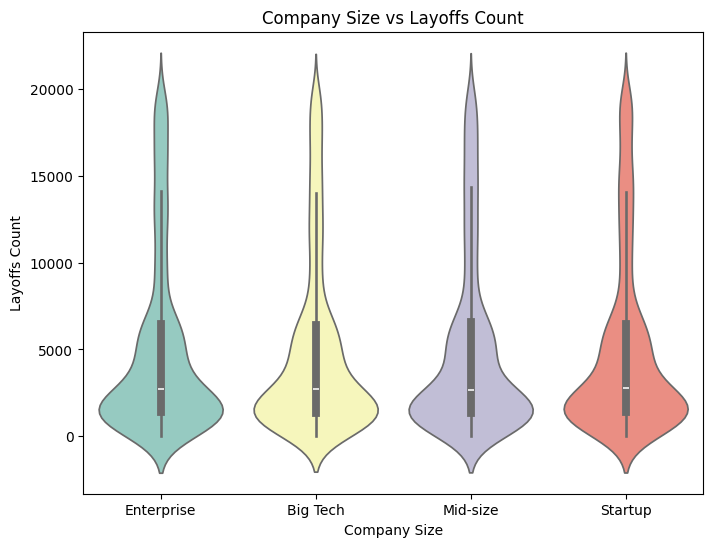

In [70]:
plt.figure(figsize=(8,6))

sns.violinplot(x='company_size',y='layoffs_count',data=df,palette='Set3')
plt.title('Company Size vs Layoffs Count')
plt.xlabel('Company Size')
plt.ylabel('Layoffs Count')
plt.show()

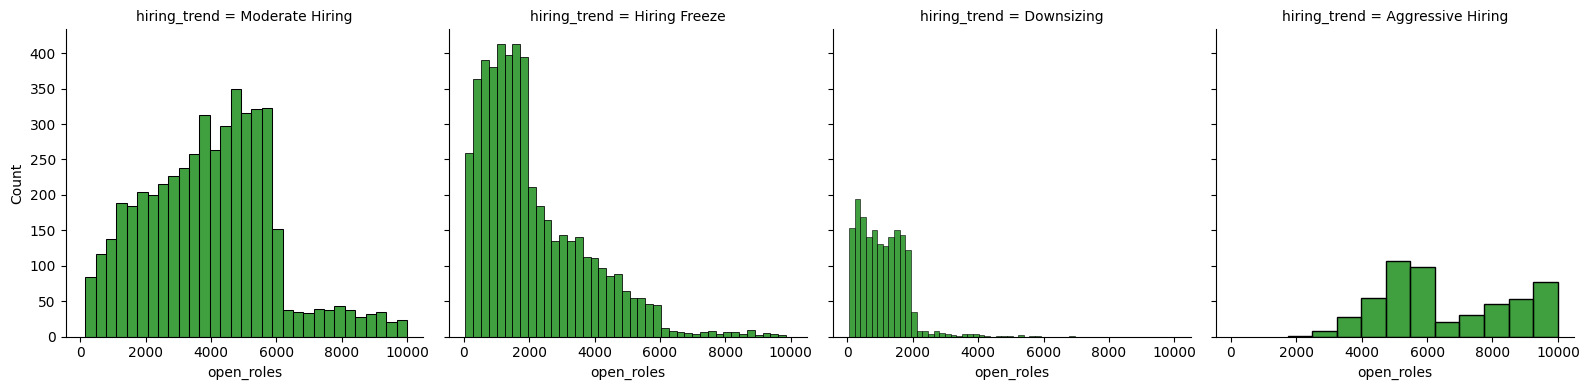

In [ ]:
g = sns.FacetGrid(df, col='hiring_trend', height=4)
g.map(sns.histplot, 'open_roles', color='green')
plt.show()